# Observed vs. true fluorescence lifetime in homoFRET

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import pandas as pd
import src.tcspc as tcspc
import src.custom_plot as cp

%load_ext autoreload
%autoreload 2

In [2]:
transitions = [['S1_S0', 1e9, "fluorescent emission", "FLU", True],
               ['S1_S0', 1e9, "internal conversion S", "ICS", False],
               ['S1_S0__S0_S1', 1e10, 'energy transfer', 'FRET', False]]

In [3]:
simulated_times = tcspc.tcspc_simulation(transitions, n_pulses=10000, seed=10)

In [4]:
fluo_prob = 1e9 / (1e9 + 1e9 + 1e10)
fret_prob = 1e10 / (1e10 + 1e9 + 1e9)
fluo_lifetime = 1 / (1e9 + 1e9 + 1e10)
accuracy = 20
size = 1000
drawn_times = tcspc.fluorescence_lifetime_distribution_hfret_rvs(fluo_prob, fret_prob, fluo_lifetime, 
                                                                 accuracy, size, seed=100)

(<Figure size 432x216 with 1 Axes>,
 array([[<AxesSubplot:xlabel='lifetime [s]', ylabel='PD'>]], dtype=object))

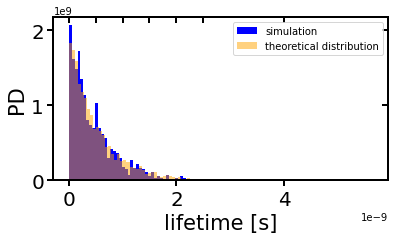

In [5]:
fig, ax = cp.universal_figure(type_='hist', data=drawn_times, density=True, bins=40, label='simulation')
cp.universal_figure(type_='hist', data=simulated_times, density=True, fig=fig, axes=ax, color='orange', alpha=0.5, bins=100,
                    ylabel='PD', xlabel='lifetime [s]', label='theoretical distribution', legend=True)

In [6]:
energy_transfer_rates = np.logspace(4, 12, num=9)

In [23]:
accuracy = 100000
size = 1000000
true_lifetimes = []
unchanged_lifetimes = []
observed_lifetimes = []
simulated_lifetimes = []
for energy_transfer_rate in energy_transfer_rates:
    transitions = [['S1_S0', 3e8, "fluorescent emission", "FLU", True],
               ['S1_S0', 7e8, "internal conversion S", "ICS", False],
               ['S1_S0__S0_S1', energy_transfer_rate, 'energy transfer', 'FRET', False]]
    true_lifetime = 1 / (3e8 + 7e8 + energy_transfer_rate)
    unchanged_lifetime = 1 / (3e8 + 7e8)
    fret_prob = energy_transfer_rate / (energy_transfer_rate + 7e8 + 3e8)
    fluo_prob = 3e8 / (energy_transfer_rate + 3e8 + 7e8)
    drawn_lifetimes = tcspc.fluorescence_lifetime_distribution_hfret_rvs(fluo_prob, fret_prob, fluo_lifetime=true_lifetime,
                                                                         accuracy=accuracy, size=size, seed=100)
    observed_lifetime = np.mean(drawn_lifetimes)
    
    sim_time = tcspc.tcspc_simulation(transitions, n_pulses=10000, seed=10)
    sim_time = np.mean(sim_time)
    
    simulated_lifetimes.append(sim_time)
    true_lifetimes.append(true_lifetime)
    unchanged_lifetimes.append(unchanged_lifetime)
    observed_lifetimes.append(observed_lifetime)

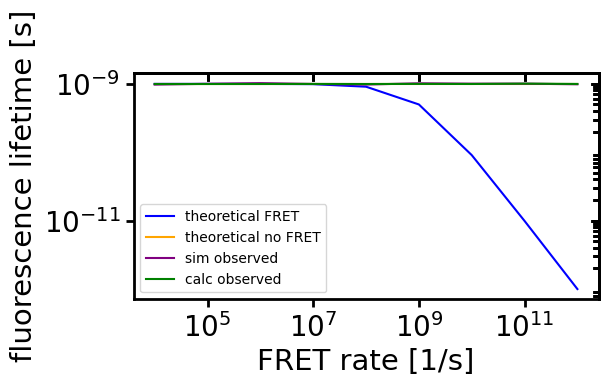

In [24]:
fig, ax = cp.universal_figure(type_='line', data=[energy_transfer_rates, true_lifetimes], yscale='log', xscale='log', label='theoretical FRET')
fig, ax = cp.universal_figure(type_='line', data=[energy_transfer_rates, unchanged_lifetimes], fig=fig, axes=ax, color='orange', label='theoretical no FRET')
fig, ax = cp.universal_figure(type_='line', data=[energy_transfer_rates, simulated_lifetimes], fig=fig, axes=ax, color='purple', label='sim observed')
fig, ax = cp.universal_figure(type_='line', data=[energy_transfer_rates, observed_lifetimes], fig=fig, axes=ax, color='green', label='calc observed', legend=True,
                              xlabel='FRET rate [1/s]', ylabel='fluorescence lifetime [s]')